# 03 - Classical Clustering
**Goal:** Use K-Means, Hierarchical, and DBSCAN clustering on the scaled RFM features to find natural customer segments — no manual thresholds, purely data-driven.

| Algorithm | Key Idea |
|-----------|----------|
| **K-Means** | Partitions customers into K clusters by minimising intra-cluster distance |
| **Hierarchical** | Builds a tree of clusters bottom-up — no need to specify K upfront |
| **DBSCAN** | Finds dense regions — great for detecting outliers/noise |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Load Data

In [2]:
rfm = pd.read_csv('../data/processed/rfm.csv')
rfm_scaled = pd.read_csv('../data/processed/rfm_scaled.csv')

X = rfm_scaled[['Recency', 'Frequency', 'Monetary']].values

print(f"RFM shape: {rfm.shape}")
print(f"Scaled RFM shape: {rfm_scaled.shape}")

RFM shape: (5862, 4)
Scaled RFM shape: (5862, 4)


## 2. K-Means Clustering

### 2.1 Finding Optimal K — Elbow Method & Silhouette Score

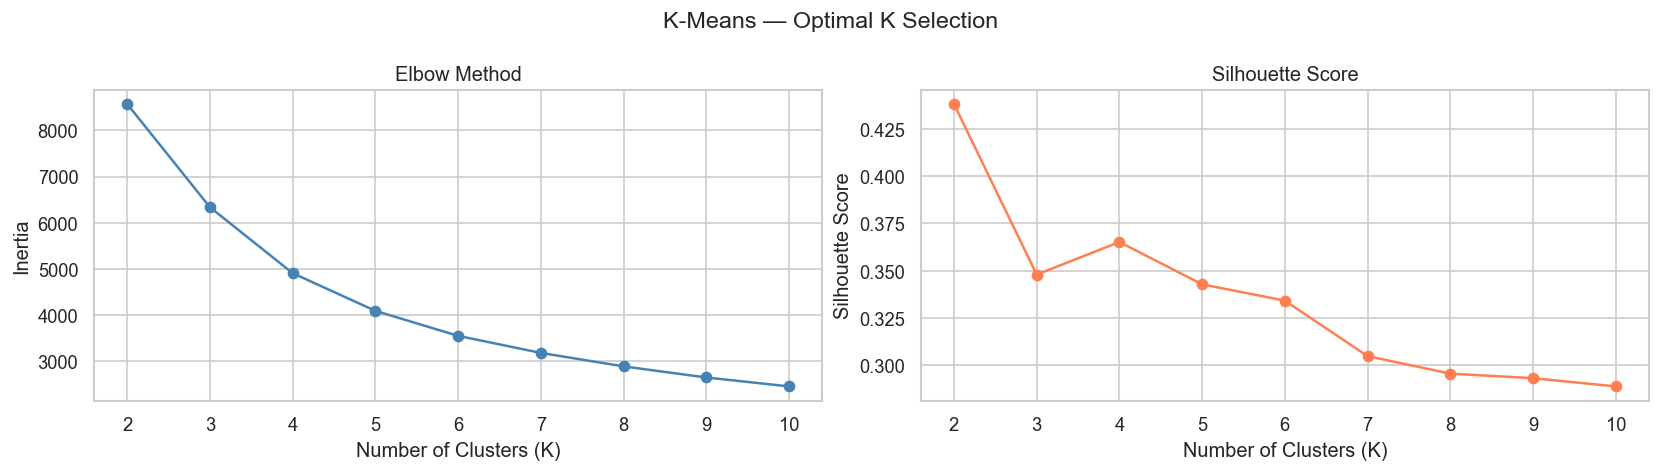

Silhouette scores:
  K=2: 0.4381
  K=3: 0.3480
  K=4: 0.3652
  K=5: 0.3428
  K=6: 0.3342
  K=7: 0.3049
  K=8: 0.2956
  K=9: 0.2932
  K=10: 0.2889


In [3]:
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(K_range, inertias, 'o-', color='steelblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, silhouettes, 'o-', color='coral')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.suptitle('K-Means — Optimal K Selection', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/kmeans_optimal_k.png')
plt.show()

print("Silhouette scores:")
for k, s in zip(K_range, silhouettes):
    print(f"  K={k}: {s:.4f}")

### Insight
- Silhouette score peaks at K=2 (0.438) but two clusters offer little business value
- **K=4 shows a local peak (0.365)** and is the optimal choice — 4 segments are interpretable and actionable
- Elbow curve confirms K=3/4 as the point of diminishing returns

### 2.2 Fit K-Means with K=4

In [4]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['KMeans_Cluster'] = km.fit_predict(X)

print(f"Silhouette Score (K=4): {silhouette_score(X, rfm['KMeans_Cluster']):.4f}")
print(f"Davies-Bouldin Score (K=4): {davies_bouldin_score(X, rfm['KMeans_Cluster']):.4f}")
print(f"\nCluster sizes:\n{rfm['KMeans_Cluster'].value_counts().sort_index()}")

Silhouette Score (K=4): 0.3652
Davies-Bouldin Score (K=4): 0.9304

Cluster sizes:
KMeans_Cluster
0    1189
1    1966
2    1249
3    1458
Name: count, dtype: int64


### 2.3 Visualise K-Means Clusters

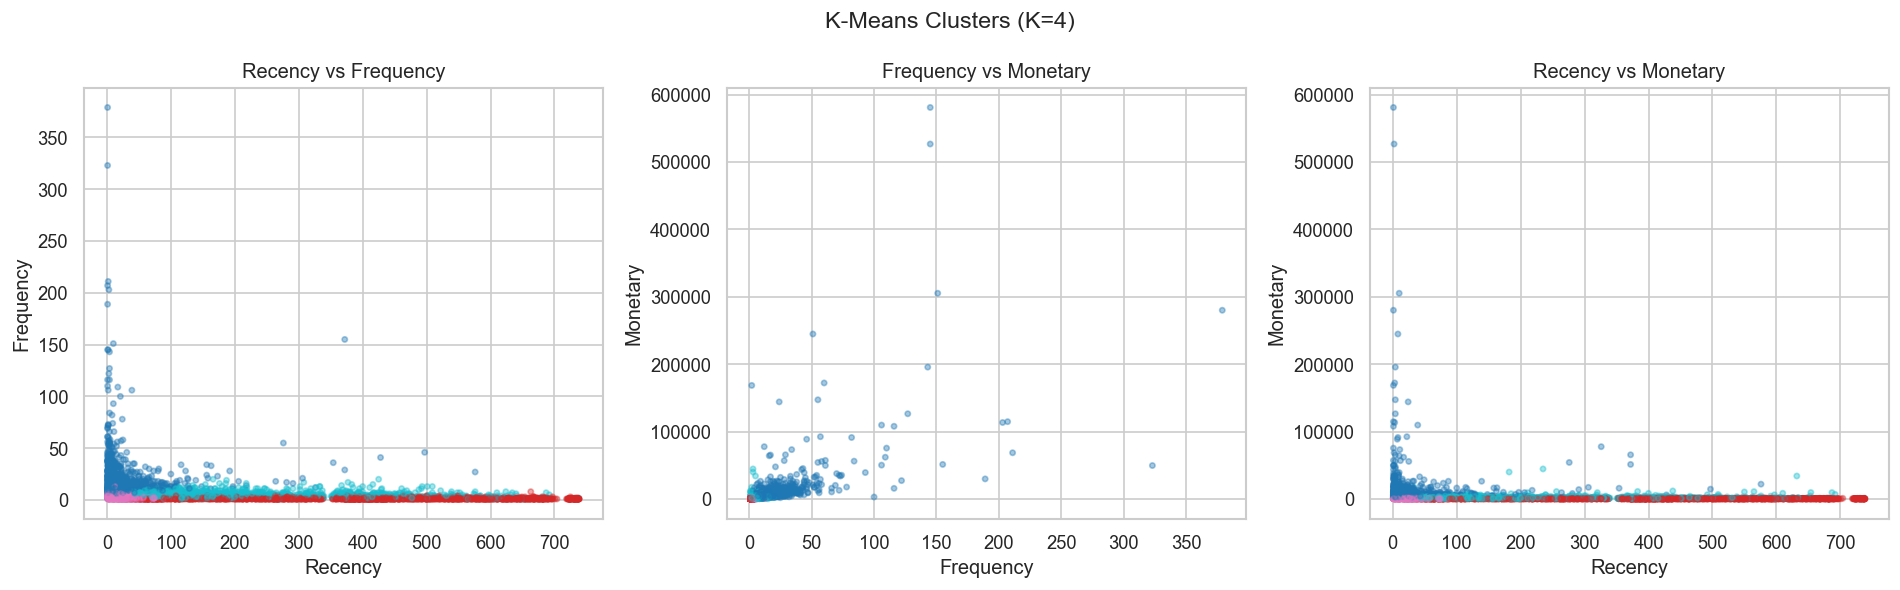

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pairs = [('Recency', 'Frequency'), ('Frequency', 'Monetary'), ('Recency', 'Monetary')]

for ax, (x, y) in zip(axes, pairs):
    scatter = ax.scatter(rfm[x], rfm[y], c=rfm['KMeans_Cluster'], 
                         cmap='tab10', alpha=0.4, s=10)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}')

plt.suptitle('K-Means Clusters (K=4)', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/kmeans_clusters.png')
plt.show()

## 3. Hierarchical Clustering

### 3.1 Dendrogram

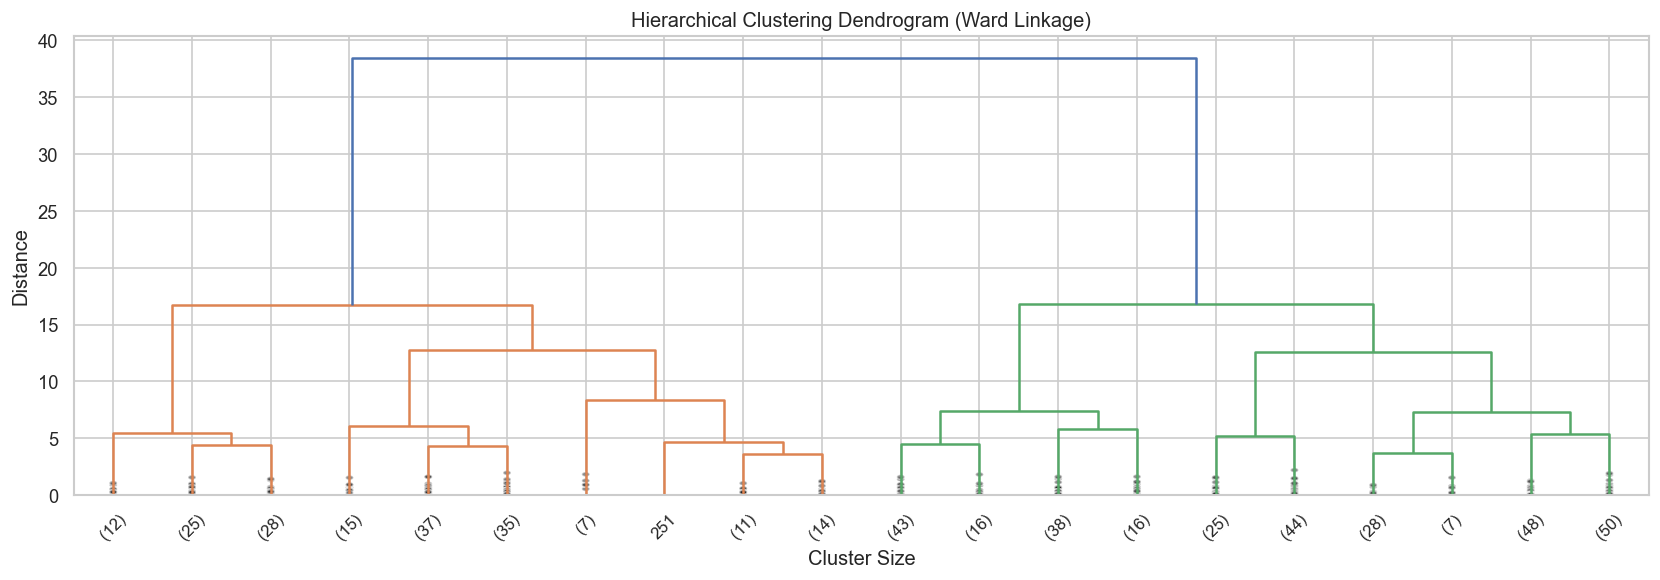

In [7]:
# Sample 500 points for dendrogram readability
np.random.seed(42)
sample_idx = np.random.choice(len(X), 500, replace=False)
X_sample = X[sample_idx]

linked = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(linked, truncate_mode='lastp', p=20,
           leaf_rotation=45, leaf_font_size=10, show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig('../reports/figures/dendrogram.png')
plt.show()

### 3.2 Fit Agglomerative Clustering with K=4

In [8]:
agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
rfm['Hierarchical_Cluster'] = agg.fit_predict(X)

sil = silhouette_score(X, rfm['Hierarchical_Cluster'])
db = davies_bouldin_score(X, rfm['Hierarchical_Cluster'])

print(f"Silhouette Score: {sil:.4f}")
print(f"Davies-Bouldin Score: {db:.4f}")
print(f"\nCluster sizes:\n{rfm['Hierarchical_Cluster'].value_counts().sort_index()}")

Silhouette Score: 0.2755
Davies-Bouldin Score: 1.0142

Cluster sizes:
Hierarchical_Cluster
0    1402
1    1510
2    1881
3    1069
Name: count, dtype: int64


### Insight
- Dendrogram confirms **K=4 as a natural cut** — two major branches each splitting into two sub-clusters
- Hierarchical clustering scores slightly lower than K-Means (Silhouette: 0.276 vs 0.365)
- Cluster sizes remain balanced (1,069 to 1,881)
- K-Means is the better performing algorithm on this dataset

## 4. DBSCAN — Outlier Detection
DBSCAN does not require specifying K upfront. It finds dense regions and labels sparse points as noise (-1).
Here we use it primarily to identify outlier customers that don't belong to any natural cluster.

In [9]:
db = DBSCAN(eps=0.5, min_samples=5)
rfm['DBSCAN_Cluster'] = db.fit_predict(X)

n_clusters = len(set(rfm['DBSCAN_Cluster'])) - (1 if -1 in rfm['DBSCAN_Cluster'].values else 0)
n_outliers = (rfm['DBSCAN_Cluster'] == -1).sum()

print(f"Clusters found: {n_clusters}")
print(f"Outliers (noise): {n_outliers} ({n_outliers/len(rfm)*100:.1f}%)")
print(f"\nCluster sizes:\n{rfm['DBSCAN_Cluster'].value_counts().sort_index()}")

Clusters found: 2
Outliers (noise): 65 (1.1%)

Cluster sizes:
DBSCAN_Cluster
-1      65
 0    4178
 1    1619
Name: count, dtype: int64


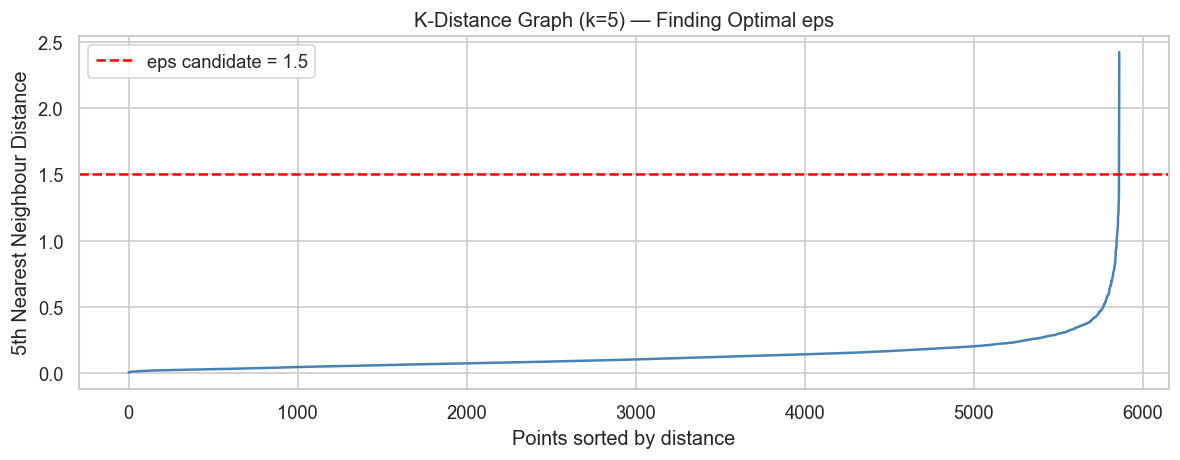

In [10]:
from sklearn.neighbors import NearestNeighbors

# Find optimal eps using k-distance graph
neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(X)
distances, _ = neighbors.kneighbors(X)
distances = np.sort(distances[:, 4])

plt.figure(figsize=(10, 4))
plt.plot(distances, color='steelblue')
plt.title('K-Distance Graph (k=5) — Finding Optimal eps')
plt.xlabel('Points sorted by distance')
plt.ylabel('5th Nearest Neighbour Distance')
plt.axhline(y=1.5, color='red', linestyle='--', label='eps candidate = 1.5')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/dbscan_kdistance.png')
plt.show()

In [11]:
db = DBSCAN(eps=1.5, min_samples=5)
rfm['DBSCAN_Cluster'] = db.fit_predict(X)

n_clusters = len(set(rfm['DBSCAN_Cluster'])) - (1 if -1 in rfm['DBSCAN_Cluster'].values else 0)
n_outliers = (rfm['DBSCAN_Cluster'] == -1).sum()

print(f"Clusters found: {n_clusters}")
print(f"Outliers (noise): {n_outliers} ({n_outliers/len(rfm)*100:.1f}%)")
print(f"\nCluster sizes:\n{rfm['DBSCAN_Cluster'].value_counts().sort_index()}")

# Show outlier customer profiles
outliers = rfm[rfm['DBSCAN_Cluster'] == -1][['Customer ID', 'Recency', 'Frequency', 'Monetary']]
print(f"\nSample outlier profiles:")
print(outliers.describe().round(2))

Clusters found: 1
Outliers (noise): 1 (0.0%)

Cluster sizes:
DBSCAN_Cluster
-1       1
 0    5861
Name: count, dtype: int64

Sample outlier profiles:
       Customer ID  Recency  Frequency  Monetary
count          1.0      1.0        1.0       1.0
mean       16446.0      1.0        2.0  168472.5
std            NaN      NaN        NaN       NaN
min        16446.0      1.0        2.0  168472.5
25%        16446.0      1.0        2.0  168472.5
50%        16446.0      1.0        2.0  168472.5
75%        16446.0      1.0        2.0  168472.5
max        16446.0      1.0        2.0  168472.5


### Insight
- The k-distance graph shows the data is uniformly dense in scaled space with only extreme outliers at the tail
- DBSCAN struggles to find meaningful clusters in this dataset regardless of eps tuning
- This is a known limitation of DBSCAN on RFM data — it works best with irregular, non-spherical clusters and clear density gaps
- **One true outlier identified: Customer 16446** — 1 day recency, 2 orders, but £168,472 spend — a clear wholesale anomaly
- Conclusion: DBSCAN is not appropriate for this dataset; K-Means remains our primary algorithm

## 5. Algorithm Comparison

In [12]:
results = pd.DataFrame({
    'Algorithm': ['K-Means (K=4)', 'Hierarchical (K=4)', 'DBSCAN (eps=1.5)'],
    'N Clusters': [4, 4, 1],
    'Silhouette Score': [0.3652, 0.2755, 'N/A'],
    'Davies-Bouldin Score': [0.9304, 1.0142, 'N/A'],
    'Balanced Clusters': ['Yes', 'Yes', 'No'],
    'Verdict': ['✅ Best', '✔ Good', '❌ Not suitable']
})

print(results.to_string(index=False))

         Algorithm  N Clusters Silhouette Score Davies-Bouldin Score Balanced Clusters        Verdict
     K-Means (K=4)           4           0.3652               0.9304               Yes         ✅ Best
Hierarchical (K=4)           4           0.2755               1.0142               Yes         ✔ Good
  DBSCAN (eps=1.5)           1              N/A                  N/A                No ❌ Not suitable


## 6. Conclusion
**K-Means with K=4 is our chosen algorithm** based on:
- Highest Silhouette Score (0.365)
- Lowest Davies-Bouldin Score (0.930)
- Balanced cluster sizes
- Dendrogram independently confirms K=4 as a natural cut

K-Means cluster labels will be carried forward into Notebook 4 for profiling and business interpretation.

## 7. Save Results

In [14]:
rfm.to_csv('../data/processed/rfm_clustered.csv', index=False)
print("Saved rfm_clustered.csv ✓")
print(f"Columns: {rfm.columns.tolist()}")

Saved rfm_clustered.csv ✓
Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'KMeans_Cluster', 'Hierarchical_Cluster', 'DBSCAN_Cluster']
